In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
class Model(nn.Module):
    #Iris dta set 
    #input layer 4- feature
    #hidden layer 1
    #hidden layer 2
    #output layer 3 classes
    
    def __init__(self, input_feature=4, h1=8, h2 = 9, out_features =3):
        super().__init__() # insrantiate nn.module
        
        self.fc1= nn.Linear(input_feature, h1)
        self.fc2= nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        
        return x

In [3]:
torch.manual_seed(42)

model = Model()

In [4]:
url = './data/iris.csv'
my_df = pd.read_csv(url)

In [5]:
my_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
my_df = my_df.drop(columns=['Id'], axis=1)
my_df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [7]:
my_df['Species'] = my_df['Species'].replace('Iris-setosa', 0.0)
my_df['Species'] = my_df['Species'].replace('Iris-versicolor', 2.0)
my_df['Species'] = my_df['Species'].replace('Iris-virginica', 2.0)
my_df

C:\Users\ravin\AppData\Local\Temp\ipykernel_19972\1632500221.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['Species'] = my_df['Species'].replace('Iris-virginica', 2.0)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [8]:
x = my_df.drop('Species', axis=1)
y = my_df['Species']
x,y

(     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
 0              5.1           3.5            1.4           0.2
 1              4.9           3.0            1.4           0.2
 2              4.7           3.2            1.3           0.2
 3              4.6           3.1            1.5           0.2
 4              5.0           3.6            1.4           0.2
 ..             ...           ...            ...           ...
 145            6.7           3.0            5.2           2.3
 146            6.3           2.5            5.0           1.9
 147            6.5           3.0            5.2           2.0
 148            6.2           3.4            5.4           2.3
 149            5.9           3.0            5.1           1.8
 
 [150 rows x 4 columns],
 0      0.0
 1      0.0
 2      0.0
 3      0.0
 4      0.0
       ... 
 145    2.0
 146    2.0
 147    2.0
 148    2.0
 149    2.0
 Name: Species, Length: 150, dtype: float64)

In [9]:
#convert to numpy array
x = x.values
y = y.values


In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [11]:
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [12]:
# set the critariance of model tomeasurer the error, how far of the prediction are from the data
critariance = nn.CrossEntropyLoss()
#choose adam optimizer , lertning rate (if errie does not go after a bunch of itrtations(epochd) , lower our learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [13]:
#train the model
epoches =100
losses = []
for i in range (epoches):
    y_pred = model.forward(x_train)
    
    #mesure the loss gonna be high at first
    loss = critariance(y_pred,y_train)
    
    
    #keep tack of our losses
    losses.append(loss.detach().numpy())
    
    #print every epoch
    if i % 10  == 0:
        print(f"epoch {i} and loss {loss}")
        
    #do some back propagation take the error rate of forward propagation and feed back thri the network  to find the weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

epoch 0 and loss 1.269836187362671
epoch 10 and loss 0.6509705185890198
epoch 20 and loss 0.3550715148448944
epoch 30 and loss 0.13279734551906586
epoch 40 and loss 0.030306058004498482
epoch 50 and loss 0.008570000529289246
epoch 60 and loss 0.0037769009359180927
epoch 70 and loss 0.0023073728661984205
epoch 80 and loss 0.0017356290481984615
epoch 90 and loss 0.0014244535705074668


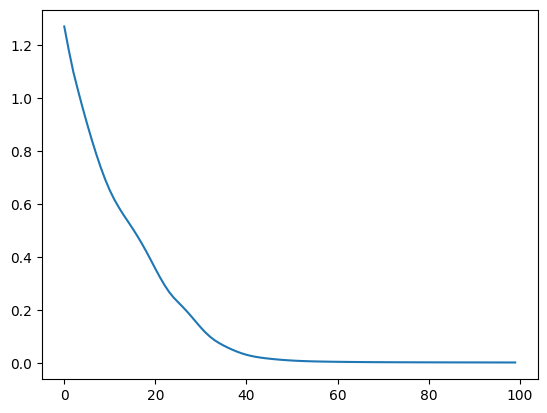

In [14]:
plt.plot(range(epoches), losses)


In [15]:
#evaluate model on test fata set 
with torch.no_grad():#turn off back popagation
    y_eval = model.forward(x_test)
    loss = critariance(y_eval, y_test)

In [16]:
loss

tensor(0.0011)

In [17]:
correct =0
with torch.no_grad():
    for i, data in enumerate(x_test):
        y_val = model.forward(data)
        
        #will tell us what type of flower cladd our network predict
        print(f"{i+1}.) {str(y_val)} \t {y_test[i]}")

1.) tensor([-5.2685, -6.5006,  4.5373]) 	 2
2.) tensor([ 3.5116, -6.9693, -3.4223]) 	 0
3.) tensor([-10.3304,  -8.4242,   8.0867]) 	 2
4.) tensor([-4.8768, -6.6942,  4.1808]) 	 2
5.) tensor([-5.7237, -6.9952,  4.9053]) 	 2
6.) tensor([ 3.2712, -6.6199, -3.1393]) 	 0
7.) tensor([-2.7355, -6.5124,  2.2878]) 	 2
8.) tensor([-6.4464, -7.6727,  5.5105]) 	 2
9.) tensor([-5.9680, -6.4357,  5.1525]) 	 2
10.) tensor([-3.6692, -6.3959,  3.1365]) 	 2
11.) tensor([-5.9940, -7.3540,  5.1150]) 	 2
12.) tensor([ 3.1218, -5.8652, -2.9235]) 	 0
13.) tensor([ 3.9905, -6.6741, -3.8020]) 	 0
14.) tensor([ 3.0525, -5.9722, -2.8796]) 	 0
15.) tensor([ 4.0205, -6.6515, -3.8434]) 	 0
16.) tensor([-4.7714, -7.1470,  4.0193]) 	 2
17.) tensor([-7.5803, -7.4948,  6.2915]) 	 2
18.) tensor([-3.9007, -6.0967,  3.3799]) 	 2
19.) tensor([-4.8207, -6.3573,  4.1596]) 	 2
20.) tensor([-7.4658, -7.3566,  6.1993]) 	 2
21.) tensor([ 2.9500, -5.9575, -2.7877]) 	 0
22.) tensor([-5.6820, -6.9232,  4.8833]) 	 2
23.) tensor([ 3.

In [18]:
new_iris = torch.tensor([5.8, 3.1, 4.9, 1.7])

with torch.no_grad():
    print(model(new_iris))

tensor([-5.3758, -6.7669,  4.6134])


In [19]:
# save 

torch.save(model.state_dict(), './models/iris_model.pt')

In [20]:
#load model 
new_model = Model()
new_model.load_state_dict(torch.load('./models/iris_model.pt'))

C:\Users\ravin\AppData\Local\Temp\ipykernel_19972\3113078484.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  new_model.load_state_dict(torch.load('./models/iris_model.pt

<All keys matched successfully>

In [21]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)